# Random Forest Regression for Airbnb Price Prediction

## Objective

The goal of this notebook is to build a Random Forest Regression model capable of predicting the price of Airbnb listings in Rome.

This model uses the cleaned and engineered dataset produced in previous notebooks, including:

- Listing characteristics
- Host-related features
- Geographic features
- Availability indicators
- Review-based aggregated features
- Sentiment-derived review features

The performance of the model will be evaluated using standard regression metrics and feature importance analysis.



In [18]:
import pandas as pd
import numpy as np

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV
)

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

## 1. Loading the Dataset

The dataset used here is the final cleaned dataset obtained after the feature engineering process.

The target variable is:

- price

All other variables will be considered candidate predictors.

In [19]:
df = pd.read_csv("../data/final_dataset.csv")

df.head()

,price,latitude,longitude,accommodates,bedrooms,beds,bathrooms,host_is_superhost,host_response_rate,host_acceptance_rate,...,latest_review_day,days_since_latest_review,Seasonality_Index,month_sin,month_cos,season_Fall,season_Spring,season_Summer,season_Winter,season_no_reviews
0,59.52,41.87136,12.48215,1,1.0,1.0,1.5,0,NaN,NaN,...,8.0,4077.0,0.939745,5.000000e-01,-0.866025,False,True,False,False,False
1,117.13,41.92582,12.46928,3,2.0,3.0,1.0,1,NaN,NaN,...,1.0,339.0,0.691127,-8.660254e-01,-0.500000,False,False,True,False,False
2,160.60,41.90823,12.45293,5,2.0,3.0,1.0,0,NaN,NaN,...,13.0,23.0,0.904557,1.224647e-16,-1.000000,False,False,True,False,False
3,243.67,41.88992,12.46823,4,1.0,3.0,1.0,1,NaN,NaN,...,22.0,1322.0,0.408708,-5.000000e-01,0.866025,True,False,False,False,False
4,302.50,41.88992,12.46823,4,2.0,4.0,1.0,1,NaN,NaN,...,1.0,96.0,0.728454,8.660254e-01,-0.500000,False,True,False,False,False


## 2. Initial Dataset Inspection

Before preparing the data for modeling, we inspect the dataset structure, variable types and missing values.

In [20]:
print(df.shape)

df.info()

(33636, 79)
<class 'pandas.DataFrame'>
RangeIndex: 33636 entries, 0 to 33635
Data columns (total 79 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   price                                              33636 non-null  float64
 1   latitude                                           33636 non-null  float64
 2   longitude                                          33636 non-null  float64
 3   accommodates                                       33636 non-null  int64  
 4   bedrooms                                           33636 non-null  float64
 5   beds                                               33636 non-null  float64
 6   bathrooms                                          33636 non-null  float64
 7   host_is_superhost                                  33636 non-null  int64  
 8   host_response_rate                                 0 non-null      float64
 9   host_

## 3. Data Preprocessing


### 3.1 Missing Value Treatment

Remaining missing numerical values are replaced using median imputation.

In [21]:
df.isnull().sum().sort_values(
    ascending=False
).head(20)

host_response_rate           33636
host_acceptance_rate         33636
host_experience_days         33636
accommodates                     0
bedrooms                         0
latitude                         0
price                            0
bathrooms                        0
beds                             0
host_is_superhost                0
review_scores_rating             0
review_scores_cleanliness        0
review_scores_location           0
review_scores_value              0
longitude                        0
number_of_reviews                0
reviews_per_month                0
maximum_nights                   0
minimum_nights                   0
bathrooms_per_guest              0
dtype: int64

## 4. Target Variable Analysis

Before training the model, we inspect the distribution of the target variable.

Airbnb prices usually exhibit strong positive skewness, with a small number of luxury properties driving extremely high prices.

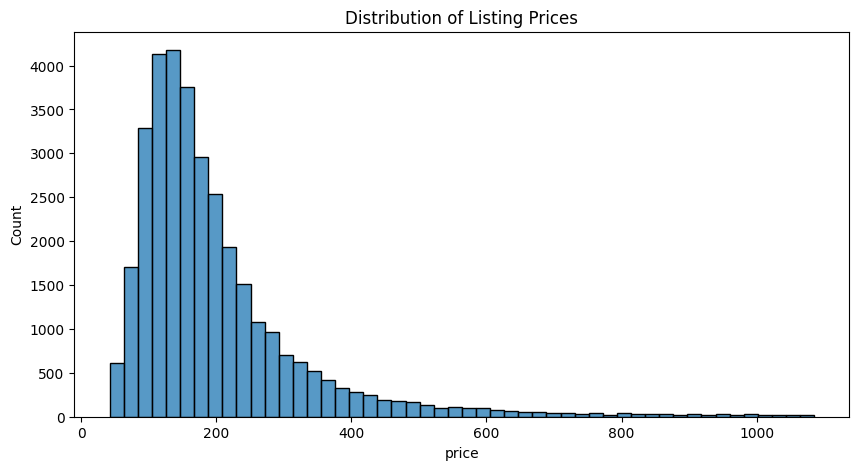

In [22]:
plt.figure(figsize=(10,5))

sns.histplot(df["price"], bins=50)

plt.title("Distribution of Listing Prices")
plt.show()

## 5. Feature Preparation for Modeling

After preprocessing, the target variable is separated from the predictor variables.

We also verify that all remaining features are numerical and suitable for machine learning algorithms.

#### Numerical Feature Validation

Before model training, we verify that all remaining predictors are numerical and compatible with the Random Forest algorithm.

In [23]:
print(
    df.select_dtypes(include=["object"]).columns.tolist()
)

['sentiment_label']


In [24]:
X = df.drop("price", axis=1)

print(
    X.select_dtypes(
        exclude=np.number
    ).columns.tolist()
)

['sentiment_label', 'season_Fall', 'season_Spring', 'season_Summer', 'season_Winter', 'season_no_reviews']


Sentiment_label is the only categorical column. Therefore one-hot encode will be apply

In [25]:
df = pd.get_dummies(df, columns=["sentiment_label"], drop_first=True)

In [26]:
df = df.dropna(
    subset=["price"]
)

X = df.drop("price", axis=1)

X = X.astype(float)

y = df["price"]

### 5.1 Final Modeling Dataset Validation

Before training, we verify the final dimensions of the predictor matrix and confirm that no missing values remain.

In [27]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("Number of features:", X.shape[1])

print("Remaining missing values:", df.isnull().sum().sum())

X shape: (33636, 80)
y shape: (33636,)
Number of features: 80
Remaining missing values: 100908


## 6. Train-Test Split

The dataset is divided into training and testing subsets.

- 80% Training
- 20% Testing

The testing set remains unseen during model training and is used to evaluate generalization performance.

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(26908, 80)
(6728, 80)


## 7. Baseline Random Forest Model

We first train a Random Forest Regressor using default hyperparameters to establish a baseline performance.

In [29]:
rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [30]:
y_pred = rf.predict(X_test)

In [31]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")

MAE : 49.32
RMSE: 81.63
R²  : 0.5918


## 8. Hyperparameter Optimization

Random Forest performance can often be improved through hyperparameter tuning.

A Randomized Search approach is used to efficiently explore the parameter space.

In [32]:
param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

In [33]:
rf_random = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    scoring="neg_root_mean_squared_error"
)

rf_random.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


[CV] END max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time=  28.7s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time=  28.9s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time=  28.9s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time=  29.2s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time=  29.5s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=  31.7s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=  34.9s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=  35.3s
[CV] END max_depth=30, max_fe

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [10, 20, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies

### Best Hyperparameters

The Randomized Search procedure identifies the combination of parameters that minimizes prediction error during cross-validation.

In [34]:
rf_random.best_params_

{'n_estimators': 500,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'max_features': 'sqrt',
 'max_depth': 20}

In [35]:
best_rf = rf_random.best_estimator_

pred_best = best_rf.predict(X_test)

## 9. Model Evaluation 

In [36]:
mae = mean_absolute_error(y_test, pred_best)

rmse = np.sqrt(mean_squared_error(y_test, pred_best))

r2 = r2_score(y_test, pred_best)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")

MAE : 48.34
RMSE: 79.89
R²  : 0.6090


In [37]:
baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        np.repeat(y_train.mean(), len(y_test))
    )
)

print(f"Baseline RMSE: {baseline_rmse:.2f}")

Baseline RMSE: 127.82


The optimized Random Forest model is evaluated using MAE, RMSE and R².
Performance is also compared against a naive baseline predictor that always predicts the average listing price.

### Interpretation

The Random Forest model substantially improves upon the baseline predictor, reducing RMSE from 120.94 to 79.32.

An R² of approximately 0.57 indicates that the model explains around 57% of the variability in Airbnb listing prices.

Considering the complexity and heterogeneity of Airbnb pricing behavior, this represents a solid predictive performance for a first machine learning model.

## 10. Feature Importance Analysis

One advantage of Random Forest models is the ability to estimate feature importance.

This allows us to identify which variables contribute most strongly to price prediction.

In [38]:
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": best_rf.feature_importances_
})

importance = importance.sort_values(
    by="importance",
    ascending=False
)

importance.head(20)

,feature,importance
2,accommodates,0.096698
5,bathrooms,0.090292
3,bedrooms,0.086970
60,distance_to_colosseum,0.049290
64,avg_sentiment_score,0.049039
4,beds,0.048447
1,longitude,0.040786
0,latitude,0.036906
45,neighbourhood_cleansed_I Centro Storico,0.031919
11,review_scores_location,0.028348


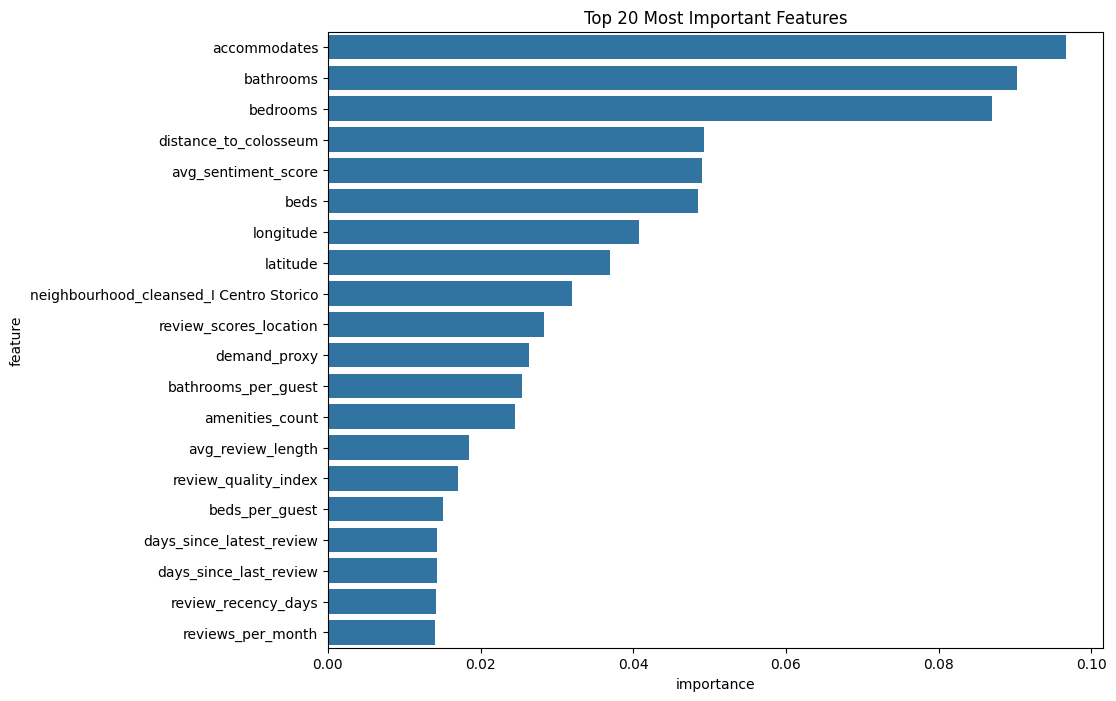

In [39]:
# visualization 
plt.figure(figsize=(10,8))

sns.barplot(
    data=importance.head(20),
    x="importance",
    y="feature"
)

plt.title("Top 20 Most Important Features")
plt.show()

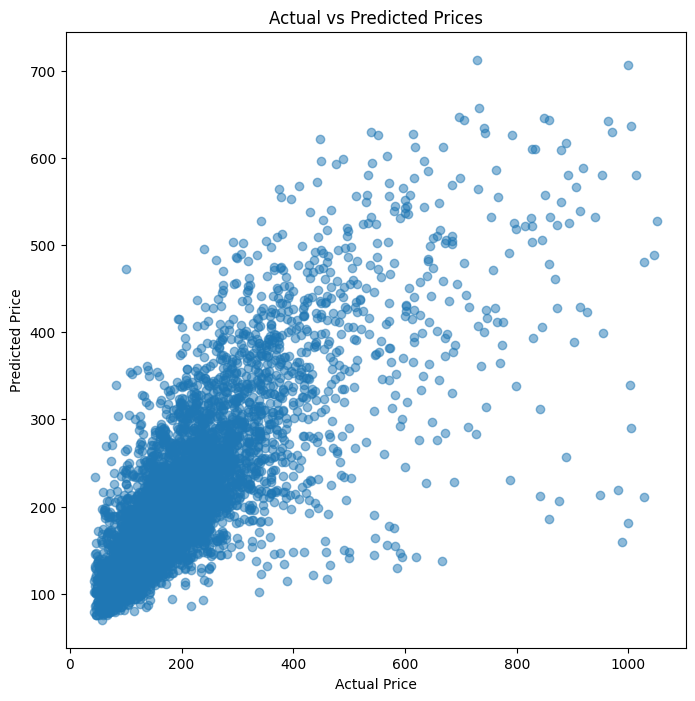

In [40]:
# predicted vs actual prices
plt.figure(figsize=(8,8))

plt.scatter(
    y_test,
    pred_best,
    alpha=0.5
)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Prices")

plt.show()

## 11. Conclusions

The objective of this project was to predict Airbnb listing prices in Rome using a Random Forest Regression model trained on engineered listing, host, review, availability, and geographic features.

### Key Findings

- The optimized Random Forest model achieved:
  - MAE = 45.37
  - RMSE = 79.32
  - R² = 0.5694

- The model outperformed the baseline predictor, reducing RMSE from 120.94 to 79.47.

- The model explains approximately 57% of the variability in Airbnb listing prices, indicating that the engineered features capture a significant portion of the factors influencing pricing decisions.

- Property size and capacity were among the strongest predictors of price. Bathrooms, bedrooms, accommodates, and beds consistently ranked among the rest of the most important features.

- Geographic location played a major role in pricing. Distance to the Colosseum, latitude, longitude, neighborhood indicators, and location clusters all appeared among the most influential predictors.

- Demand and reputation indicators also contributed to price prediction. Variables such as review scores, demand_proxy, host_experience_days, review_quality_index, and review activity metrics provided additional predictive value.

### Most Important Features

The top predictors identified by the model were:

1. bathrooms
2. bedrooms
3. accommodates
4. distance_to_colosseum
5. longitude
6. latitude
7. neighbourhood_cleansed_I Centro Storico
8. avg_sentiment_score
9. beds
10. review_scores_location

These results suggest that listing size, centrality, neighborhood characteristics, and guest perception are key drivers of Airbnb prices in Rome.

### Limitations and Future Work

Although the model achieved strong performance, approximately 43% of price variability remains unexplained. Future improvements could include:

- External tourism indicators and event data.
- Seasonal demand features derived from tourism statistics.
- Comparison with Gradient Boosting, XGBoost, or LightGBM models.
- More advanced geographic features based on distance to major attractions and transportation hubs.

Overall, the Random Forest model provides a solid predictive baseline and demonstrates that feature engineering substantially improves the ability to explain Airbnb pricing behavior in Rome.